Index(['Bus 1', 'Bus 2'], dtype='str', name='name')
Index(['Natural Gas Plant', 'Solar Plant', 'Wind Farm'], dtype='str', name='name')
Index(['Line1'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96 primals, 240 duals
Objective: 2.89e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


name                 Natural Gas Plant  Solar Plant  Wind Farm
snapshot                                                      
2024-01-01 00:00:00          -0.000000         -0.0  50.000000
2024-01-01 01:00:00          -0.000000         -0.0  50.000000
2024-01-01 02:00:00          -0.000000         -0.0  50.000000
2024-01-01 03:00:00          -0.000000         -0.0  50.000000
2024-01-01 04:00:00          -0.000000         -0.0  50.000000
2024-01-01 05:00:00          13.454669         -0.0  36.545331
2024-01-01 06:00:00          -0.000000         -0.0  50.000000
2024-01-01 07:00:00          -0.000000         50.0  -0.000000
2024-01-01 08:00:00          -0.000000         50.0  -0.000000
2024-01-01 09:00:00          -0.000000         50.0  -0.000000
2024-01-01 10:00:00          -0.000000         50.0  -0.000000
2024-01-01 11:00:00          -0.000000         50.0  -0.000000
2024-01-01 12:00:00          -0.000000         50.0  -0.000000
2024-01-01 13:00:00          -0.000000         50.0  -0

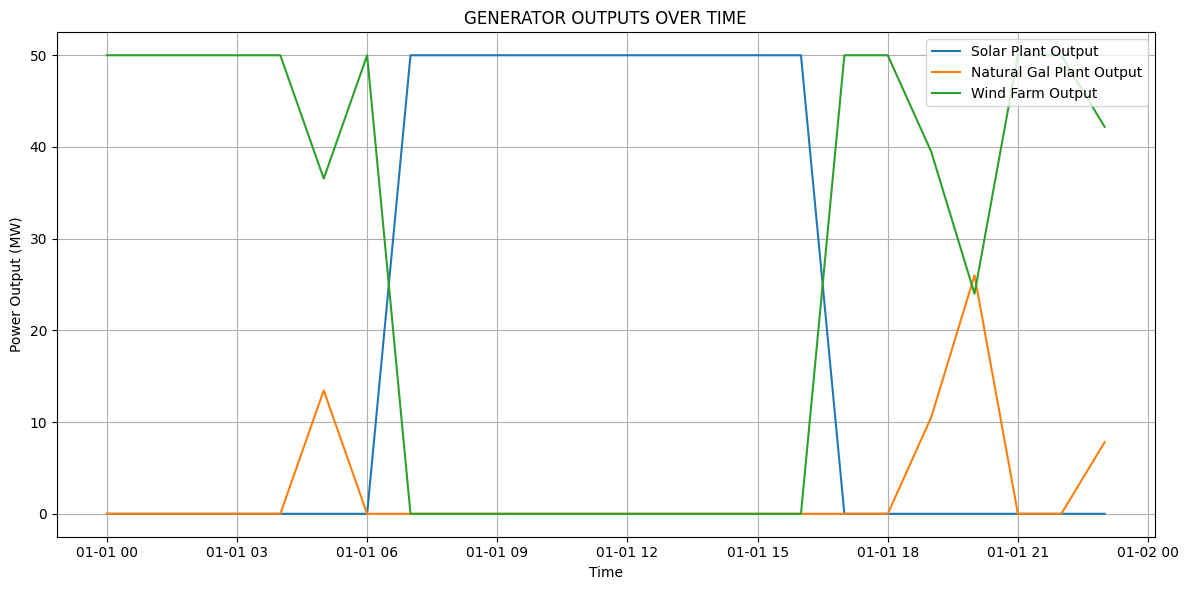


--- Συνολική Ενέργεια ανά Πηγή (MWh) ---
name
Natural Gas Plant     57.764927
Solar Plant          500.000000
Wind Farm            642.235073
dtype: float64


In [6]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

network = pypsa.Network()


# 1. Προσθήκη Κόμβων (Bus 1: Παραγωγή, Bus 2: Φορτίο)
network.add("Bus", "Bus 1", carrier="AC", x=0, y=0)
network.add("Bus", "Bus 2", carrier="AC", x=1, y=0)

# 2. Προσθήκη Γραμμής Μεταφοράς (Σύνδεση Bus 1 -> Bus 2)
network.add("Line", "Line1", 
            bus0="Bus 1", bus1="Bus 2", 
            x=0.1,
            r=0.01, 
            s_nom=200,
            carrier = "AC"
            )

# 3. Προσθήκη Σταθερού Φορτίου στον Bus 2
network.add("Load", "Load1", bus="Bus 2", p_set=50) # 50 MW σταθερά

# 4. Προσθήκη Γεννητριών στον Bus 1

network.add("Generator", "Natural Gas Plant", bus="Bus 1", 
            p_nom=40, marginal_cost=50, carrier = "gas")

network.add("Generator", "Solar Plant", bus="Bus 1", 
            p_nom=200, marginal_cost=0, carrier = "solar")

network.add("Generator", "Wind Farm", bus="Bus 1", 
            p_nom=120, marginal_cost=0, carrier="wind")

# 5. Ορισμός στιγμιοτύπων για ένα 24 ωρο
hours = pd.date_range('2024-01-01 00:00', '2024-01-01 23:00', freq='h')

network.set_snapshots(hours)

# 6. Solar Curve & Wind Generation
angle_range = np.linspace(-np.pi/2, 3*np.pi/2, len(hours))
solar_output = np.maximum(0, np.sin(angle_range))

np.random.seed(0)
wind_output = np.random.normal(0.5, 0.2, len(hours))
wind_output = np.clip(wind_output, 0.2, 1)

network.generators_t.p_max_pu = pd.DataFrame({
  'Solar Plant' : solar_output,
  'Wind Farm' : wind_output
}, index=hours)

# 7. Επίλυση
network.optimize(solver_name='highs')
results = network.generators_t.p
print(results)

# --- Οπτικοποίηση ---


plt.figure(figsize=(12, 6))
plt.plot(results.index, results["Solar Plant"], label='Solar Plant Output')

plt.plot(results.index, results["Natural Gas Plant"], label='Natural Gal Plant Output')

plt.plot(results.index, results["Wind Farm"], label='Wind Farm Output')

plt.xlabel('Time')
plt.ylabel('Power Output (MW)')
plt.title("GENERATOR OUTPUTS OVER TIME")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Εκτύπωση αποτελεσμάτων
print("\n--- Συνολική Ενέργεια ανά Πηγή (MWh) ---")
print(network.generators_t.p.sum())